# 1. 加载训练数据

In [1]:
import os
import pathlib
import requests
import tqdm
import numpy as np
import gzip
import matplotlib.pyplot as plt


In [2]:
train_images_filename = 'data/train-images-idx3-ubyte.gz'
train_labels_filename = 'data/train-labels-idx1-ubyte.gz'
test_images_filename  = 'data/t10k-images-idx3-ubyte.gz'
test_labels_filename  = 'data/t10k-labels-idx1-ubyte.gz'

validation_size = 5000

def read_mnist_image_set(images_filename):
    with gzip.GzipFile(images_filename, 'rb') as gz:
        magic = int.from_bytes(gz.read(4), 'big')
        assert magic == 2051, f'Not an MNIST image set'

        num_images = int.from_bytes(gz.read(4), 'big')
        rows = int.from_bytes(gz.read(4), 'big')
        cols = int.from_bytes(gz.read(4), 'big')

        data = np.frombuffer(gz.read(num_images * rows * cols), dtype=np.uint8)
        data = np.reshape(data, (num_images, rows * cols))
        return data

def read_mnist_label_set(labels_filename):
    with gzip.GzipFile(labels_filename, 'rb') as gz:
        magic = int.from_bytes(gz.read(4), 'big')
        assert magic == 2049, f'Not an MNIST label set'

        num_labels = int.from_bytes(gz.read(4), 'big')
        labels = np.frombuffer(gz.read(num_labels), dtype=np.uint8)
        return labels

print('\nLoading train set ...')
train_data   = read_mnist_image_set(train_images_filename) / np.float32(255)
train_labels = read_mnist_label_set(train_labels_filename)
train_data,   val_data   = train_data  [:-validation_size], train_data  [-validation_size:]
train_labels, val_labels = train_labels[:-validation_size], train_labels[-validation_size:]
print(f'train_data:   [{str(train_data.dtype)  }] {train_data.shape}')
print(f'train_labels: [{str(train_labels.dtype)}] {train_labels.shape}')
print(f'val_data:     [{str(val_data.dtype)    }] {val_data.shape}')
print(f'val_labels:   [{str(val_labels.dtype)  }] {val_labels.shape}')

print('\nLoading test set ...')
test_data   = read_mnist_image_set(test_images_filename) / np.float32(255)
test_labels = read_mnist_label_set(test_labels_filename)
print(f'test_data:   [{str(test_data.dtype)  }] {test_data.shape}')
print(f'test_labels: [{str(test_labels.dtype)}] {test_labels.shape}')



Loading train set ...
train_data:   [float32] (55000, 784)
train_labels: [uint8] (55000,)
val_data:     [float32] (5000, 784)
val_labels:   [uint8] (5000,)

Loading test set ...
test_data:   [float32] (10000, 784)
test_labels: [uint8] (10000,)


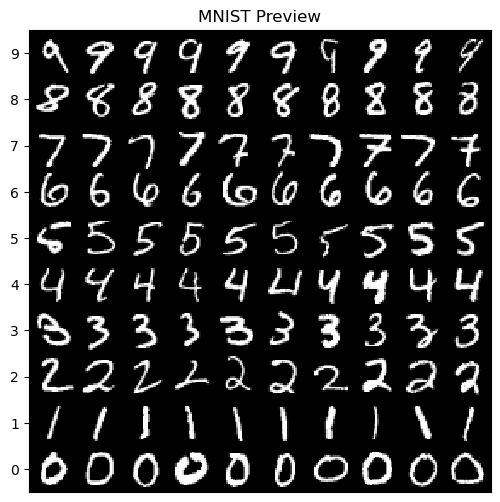

In [3]:
# Preview dataset

_ = plt.figure(figsize=(6, 6))
_ = plt.title('MNIST Preview')
for label in range(10):
    for img_index, img_data in enumerate(test_data[test_labels == label][:10]):
        _ = plt.imshow(img_data.reshape(28, 28), 'gray', vmin=0, vmax=1,
            interpolation='nearest', extent=(img_index, img_index + 1, label, label + 1))
_ = plt.xticks([])
_ = plt.yticks(np.arange(10) + 0.5, range(10))
_ = plt.xlim(0, 10)
_ = plt.ylim(0, 10)
plt.show()

# 2. 训练

In [59]:
i = np.eye(10)
print(i)
print(i[np.array([2,4])])
np.sum(np.array([[[1,2],[3,4]],[[5,6],[7,8]]]), axis=0)


[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]
[[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


array([[ 6,  8],
       [10, 12]])

loss 1.076 acc 0.720: 100%|██████████| 550/550 [00:00<00:00, 670.51it/s]


  - test loss: 0.742 acc: 0.852


loss 0.905 acc 0.730: 100%|██████████| 550/550 [00:00<00:00, 755.36it/s]


  - test loss: 0.564 acc: 0.873


loss 0.826 acc 0.740: 100%|██████████| 550/550 [00:00<00:00, 656.57it/s]


...

  - test loss: 0.383 acc: 0.900


loss 0.665 acc 0.810: 100%|██████████| 550/550 [00:00<00:00, 687.39it/s]


  - test loss: 0.374 acc: 0.902


loss 0.652 acc 0.810: 100%|██████████| 550/550 [00:00<00:00, 775.68it/s]


  - test loss: 0.366 acc: 0.903


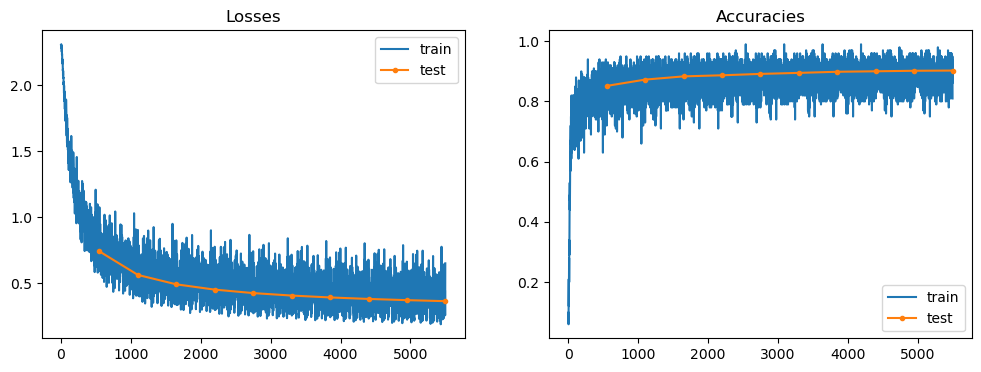


最终模型参数:
W shape: (784, 10), 范围: [-0.3419, 0.4452]
b shape: (10,), 范围: [-0.3871, 0.2719]
最终测试准确率: 0.9027


In [108]:
# 超参数
batch_size = 100
max_epoch = 10
lr = 0.001      # learning rate
momentum = 0.9   # momentum

# 初始化参数
# W: 权重矩阵 [784, 10] - 784个输入特征，10个类别
# b: 偏置向量 [10] - 10个类别的偏置
W = np.random.randn(784, 10) * 0.01     # 权重初始化
b = np.zeros(10)                         # 偏置初始化

# 动量变量
v_W = np.zeros_like(W)
v_b = np.zeros_like(b)

K = 10
train_losses = []
test_losses  = []
train_accuracies = []
test_accuracies  = []

for epoch in range(max_epoch):
    steps_per_epoch = np.ceil(len(train_data) / batch_size).astype(int)
    progress_bar = tqdm.tqdm(range(steps_per_epoch))
    
    for step_index in progress_bar:
        # 获取训练批次
        x = train_data[step_index * batch_size:(step_index + 1) * batch_size]           # [batch_size, 784]
        y_true = train_labels[step_index * batch_size:(step_index + 1) * batch_size]    # [batch_size,]
        y_true = np.eye(10)[y_true]                                                     # [batch_size, 10] one-hot编码

        # ===== 前向传播 =====
        # 1. 线性变换: z = W^T * x + b
        z = np.dot(x, W) + b  # [batch_size, 10]
        
        # 2. Softmax激活函数: y_pred = softmax(z)
        # 数值稳定的softmax实现
        z_max = np.max(z, axis=1, keepdims=True)  # [batch_size, 1]
        exp_z = np.exp(z - z_max)                  # 减去最大值避免exp溢出
        y_pred = exp_z / np.sum(exp_z, axis=1, keepdims=True)  # [batch_size, 10]
        
        # 3. 计算交叉熵损失
        N = x.shape[0]  # batch_size
        # 添加小量避免log(0)
        epsilon = 1e-15
        y_pred_clipped = np.clip(y_pred, epsilon, 1.0 - epsilon)
        loss = -1/N * np.sum(y_true * np.log(y_pred_clipped))
        
        # 4. 计算准确率
        predicted_labels = np.argmax(y_pred, axis=1)
        true_labels = np.argmax(y_true, axis=1)
        accuracy = np.mean(predicted_labels == true_labels)

        train_losses.append(loss)
        train_accuracies.append(accuracy)
        progress_bar.set_description(f'loss {loss:.3f} acc {accuracy:.3f}')
        
        # ===== 反向传播 =====
        # 5. 计算梯度
        # 交叉熵损失对softmax输出的梯度
        error = y_pred - y_true  # [batch_size, 10]
        
        # 6. 权重梯度: grad_W = (1/N) * x^T * error
        grad_W = (1/N) * np.dot(x.T, error)  # [784, 10]
        
        # 7. 偏置梯度: grad_b = (1/N) * sum(error, axis=0)
        grad_b = (1/N) * np.sum(error, axis=0)  # [10]
        
        # 8. 使用动量更新参数
        v_W = momentum * v_W - lr * grad_W
        v_b = momentum * v_b - lr * grad_b
        
        W = W + v_W
        b = b + v_b

    # 测试集评估
    x = test_data
    y_true = test_labels
    y_true = np.eye(10)[y_true]     # one-hot编码
    N = x.shape[0]
    
    # 前向传播
    z = np.dot(x, W) + b
    z_max = np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z - z_max)
    y_pred = exp_z / np.sum(exp_z, axis=1, keepdims=True)
    
    # 计算测试集损失和准确率
    y_pred_clipped = np.clip(y_pred, epsilon, 1.0 - epsilon)
    loss = -1/N * np.sum(y_true * np.log(y_pred_clipped))
    
    predicted_labels = np.argmax(y_pred, axis=1)
    true_labels = np.argmax(y_true, axis=1)
    accuracy = np.mean(predicted_labels == true_labels)

    test_losses.append(loss)
    test_accuracies.append(accuracy)
    print(f'  - test loss: {loss:.3f} acc: {accuracy:.3f}')

# 绘制损失和准确率曲线
fig, (a0, a1) = plt.subplots(1, 2, figsize=(12, 4))
_ = a0.set_title('Losses')
_ = a0.plot(train_losses, label='train')
_ = a0.plot((np.arange(max_epoch) + 1) * steps_per_epoch, test_losses, marker='.', label='test')
_ = a0.legend()
_ = a1.set_title('Accuracies')
_ = a1.plot(train_accuracies, label='train')
_ = a1.plot((np.arange(max_epoch) + 1) * steps_per_epoch, test_accuracies, marker='.', label='test')
_ = a1.legend()
plt.show()

# 打印最终模型参数信息
print(f"\n最终模型参数:")
print(f"W shape: {W.shape}, 范围: [{W.min():.4f}, {W.max():.4f}]")
print(f"b shape: {b.shape}, 范围: [{b.min():.4f}, {b.max():.4f}]")
print(f"最终测试准确率: {test_accuracies[-1]:.4f}")

开始超参数测试...
测试 lr 参数...
  lr = 0.0001
  lr = 0.0005
  lr = 0.001
  lr = 0.005
  lr = 0.01
  lr = 0.05
测试 momentum 参数...
  momentum = 0.1
  momentum = 0.3
  momentum = 0.5
  momentum = 0.7
  momentum = 0.9
  momentum = 0.95
测试 batch_size 参数...
  batch_size = 32
  batch_size = 64
  batch_size = 100
  batch_size = 128
  batch_size = 256
  batch_size = 512


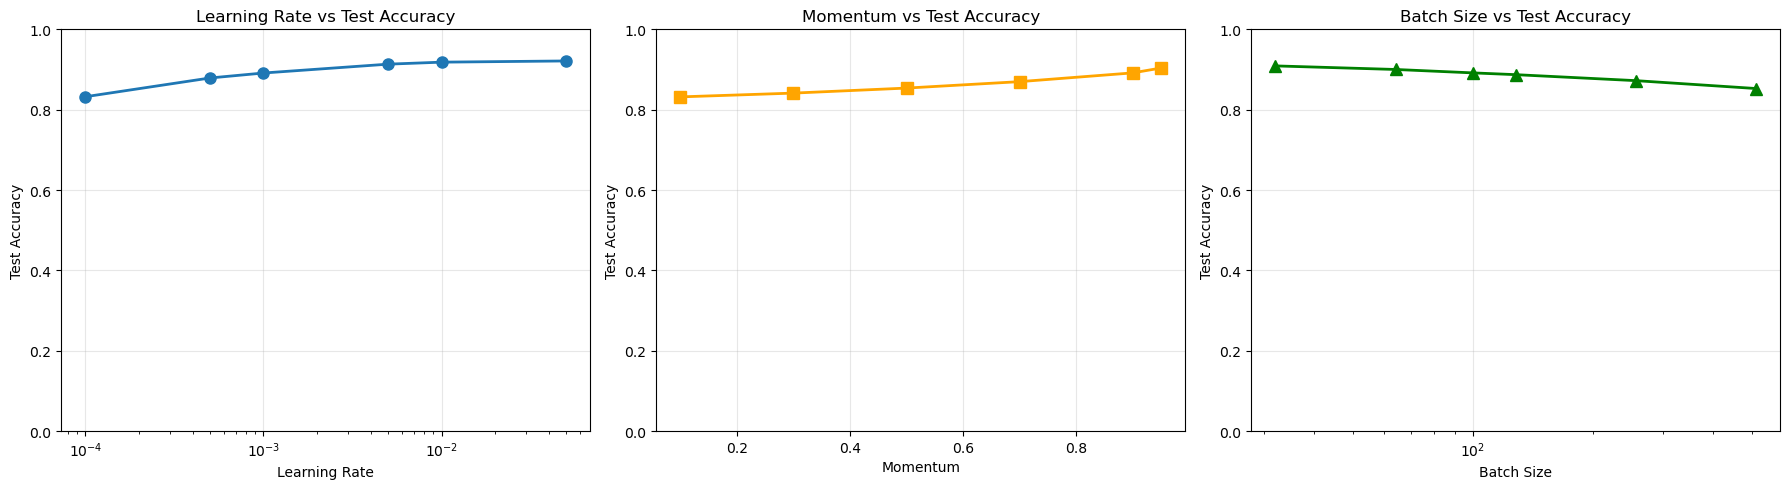


=== 超参数测试结果 ===
最佳学习率: 0.050000 (准确率: 0.9213)
最佳动量: 0.95 (准确率: 0.9037)
最佳批次大小: 32 (准确率: 0.9090)


In [109]:
# 封装超参数测试函数
def test_hyperparameters(train_data, train_labels, test_data, test_labels, 
                        param_name, param_values, fixed_params=None):
    """
    测试不同超参数对模型准确率的影响
    
    参数:
    - param_name: 要测试的超参数名称 ('lr', 'momentum', 'batch_size')
    - param_values: 要测试的超参数值列表
    - fixed_params: 固定的其他超参数字典
    
    返回:
    - param_values: 测试的超参数值
    - test_accuracies: 对应的测试准确率
    """
    
    # 默认固定参数
    if fixed_params is None:
        fixed_params = {
            'lr': 0.001,
            'momentum': 0.9,
            'batch_size': 100,
            'max_epoch': 5  # 减少epoch数以加快测试
        }
    
    # 更新固定参数
    fixed_params.update({
        'lr': fixed_params['lr'],
        'momentum': fixed_params['momentum'], 
        'batch_size': fixed_params['batch_size'],
        'max_epoch': fixed_params['max_epoch']
    })
    
    test_accuracies = []
    
    print(f"测试 {param_name} 参数...")
    
    for param_value in param_values:
        print(f"  {param_name} = {param_value}")
        
        # 更新当前测试的超参数
        current_params = fixed_params.copy()
        current_params[param_name] = param_value
        
        # 训练模型
        acc = train_and_evaluate(train_data, train_labels, test_data, test_labels, current_params)
        test_accuracies.append(acc)
    
    return param_values, test_accuracies

def train_and_evaluate(train_data, train_labels, test_data, test_labels, params):
    """
    使用给定参数训练模型并返回测试准确率
    """
    lr = params['lr']
    momentum = params['momentum']
    batch_size = params['batch_size']
    max_epoch = params['max_epoch']
    
    # 初始化参数
    W = np.random.randn(784, 10) * 0.01
    b = np.zeros(10)
    
    # 动量变量
    v_W = np.zeros_like(W)
    v_b = np.zeros_like(b)
    
    # 训练循环
    for epoch in range(max_epoch):
        steps_per_epoch = np.ceil(len(train_data) / batch_size).astype(int)
        
        for step_index in range(steps_per_epoch):
            # 获取训练批次
            x = train_data[step_index * batch_size:(step_index + 1) * batch_size]
            y_true = train_labels[step_index * batch_size:(step_index + 1) * batch_size]
            y_true = np.eye(10)[y_true]
            
            # 前向传播
            z = np.dot(x, W) + b
            z_max = np.max(z, axis=1, keepdims=True)
            exp_z = np.exp(z - z_max)
            y_pred = exp_z / np.sum(exp_z, axis=1, keepdims=True)
            
            # 计算损失
            N = x.shape[0]
            epsilon = 1e-15
            y_pred_clipped = np.clip(y_pred, epsilon, 1.0 - epsilon)
            loss = -1/N * np.sum(y_true * np.log(y_pred_clipped))
            
            # 反向传播
            error = y_pred - y_true
            grad_W = (1/N) * np.dot(x.T, error)
            grad_b = (1/N) * np.sum(error, axis=0)
            
            # 参数更新
            v_W = momentum * v_W - lr * grad_W
            v_b = momentum * v_b - lr * grad_b
            
            W = W + v_W
            b = b + v_b
    
    # 测试集评估
    x = test_data
    y_true = test_labels
    y_true = np.eye(10)[y_true]
    
    z = np.dot(x, W) + b
    z_max = np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z - z_max)
    y_pred = exp_z / np.sum(exp_z, axis=1, keepdims=True)
    
    predicted_labels = np.argmax(y_pred, axis=1)
    true_labels = np.argmax(y_true, axis=1)
    accuracy = np.mean(predicted_labels == true_labels)
    
    return accuracy

# 超参数测试
print("开始超参数测试...")

# 1. 测试学习率 (lr)
lr_values = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05]
fixed_params_lr = {'lr': 0.001, 'momentum': 0.9, 'batch_size': 100, 'max_epoch': 5}
lr_values, lr_accuracies = test_hyperparameters(
    train_data, train_labels, test_data, test_labels, 
    'lr', lr_values, fixed_params_lr
)

# 2. 测试动量 (momentum)
momentum_values = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95]
fixed_params_momentum = {'lr': 0.001, 'momentum': 0.9, 'batch_size': 100, 'max_epoch': 5}
momentum_values, momentum_accuracies = test_hyperparameters(
    train_data, train_labels, test_data, test_labels, 
    'momentum', momentum_values, fixed_params_momentum
)

# 3. 测试批次大小 (batch_size)
batch_size_values = [32, 64, 100, 128, 256, 512]
fixed_params_batch = {'lr': 0.001, 'momentum': 0.9, 'batch_size': 100, 'max_epoch': 5}
batch_size_values, batch_accuracies = test_hyperparameters(
    train_data, train_labels, test_data, test_labels, 
    'batch_size', batch_size_values, fixed_params_batch
)

# 绘制超参数与准确率的关系图
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 学习率 vs 准确率
axes[0].plot(lr_values, lr_accuracies, 'o-', linewidth=2, markersize=8)
axes[0].set_xlabel('Learning Rate')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Learning Rate vs Test Accuracy')
axes[0].set_xscale('log')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1)

# 动量 vs 准确率
axes[1].plot(momentum_values, momentum_accuracies, 's-', linewidth=2, markersize=8, color='orange')
axes[1].set_xlabel('Momentum')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Momentum vs Test Accuracy')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

# 批次大小 vs 准确率
axes[2].plot(batch_size_values, batch_accuracies, '^-', linewidth=2, markersize=8, color='green')
axes[2].set_xlabel('Batch Size')
axes[2].set_ylabel('Test Accuracy')
axes[2].set_title('Batch Size vs Test Accuracy')
axes[2].set_xscale('log')
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# 打印最佳超参数
print("\n=== 超参数测试结果 ===")
print(f"最佳学习率: {lr_values[np.argmax(lr_accuracies)]:.6f} (准确率: {np.max(lr_accuracies):.4f})")
print(f"最佳动量: {momentum_values[np.argmax(momentum_accuracies)]:.2f} (准确率: {np.max(momentum_accuracies):.4f})")
print(f"最佳批次大小: {batch_size_values[np.argmax(batch_accuracies)]} (准确率: {np.max(batch_accuracies):.4f})")


结果分析：
- 学习率影响最大: 对准确率变化最敏感
- 动量提供稳定性: 帮助模型跳出局部最优
- 批次大小平衡: 在计算效率和梯度质量间找到平衡点
- 这些超参数相互影响，需要协同调优才能获得最佳性能。